In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('../original_datasets/fleet_vehicles.csv')

print(df.info())
print(df.describe())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   vehicle_id           761 non-null    str    
 1   vehicle_type         761 non-null    str    
 2   model_name           761 non-null    str    
 3   capacity_kg          761 non-null    str    
 4   max_range_km         761 non-null    float64
 5   avg_speed_kmph       761 non-null    int64  
 6   hub_code             761 non-null    str    
 7   purchase_date        761 non-null    str    
 8   odometer_km          738 non-null    str    
 9   fleet_status         761 non-null    str    
 10  driver_id            618 non-null    str    
 11  battery_capacity_wh  143 non-null    float64
 12  last_service_date    761 non-null    str    
 13  insurance_expiry     761 non-null    str    
 14  ownership            761 non-null    str    
dtypes: float64(2), int64(1), str(12)
memory usage: 89.3

In [2]:
print(df.duplicated().sum())

25


In [3]:
df=df.drop_duplicates()

In [4]:
print(df.isna().sum())

vehicle_id               0
vehicle_type             0
model_name               0
capacity_kg              0
max_range_km             0
avg_speed_kmph           0
hub_code                 0
purchase_date            0
odometer_km             22
fleet_status             0
driver_id              140
battery_capacity_wh    596
last_service_date        0
insurance_expiry         0
ownership                0
dtype: int64


In [8]:
# 2. Clean `capacity_kg` safely (handles grams 'g', kg, uppercase 'KG', and strings)
s = df['capacity_kg'].astype(str).str.strip().str.lower()
g_mask = s.str.contains('g') & ~s.str.contains('kg')
cleaned_s = (
    s.str.replace('g', '', regex=False)
    .str.replace('kg', '', regex=False)
    .str.strip()
)
df['capacity_kg'] = pd.to_numeric(cleaned_s, errors='coerce')
df.loc[g_mask, 'capacity_kg'] = df.loc[g_mask, 'capacity_kg'] / 1000.0

# Impute remaining missing capacities using median by vehicle type
df['capacity_kg'] = df.groupby('vehicle_type')['capacity_kg'].transform(
    lambda x: x.fillna(x.median())
)

# 3. Clean `max_range_km` (Remove negative anomalies and impute using vehicle type median)
df['max_range_km'] = pd.to_numeric(df['max_range_km'], errors='coerce')
df.loc[df['max_range_km'] < 0, 'max_range_km'] = np.nan
df['max_range_km'] = df.groupby('vehicle_type')['max_range_km'].transform(
    lambda x: x.fillna(x.median())
)

# 4. Clean `odometer_km` (Handle symbols like '-' and fill nulls with median)
df['odometer_km'] = pd.to_numeric(df['odometer_km'], errors='coerce')
df['odometer_km'] = df['odometer_km'].fillna(df['odometer_km'].median())

# 5. Standardize `fleet_status` categories
df['fleet_status'] = df['fleet_status'].astype(str).str.strip().str.title()
df.loc[df['fleet_status'].str.contains('Maintenance'), 'fleet_status'] = (
    'Maintenance'
)
df.loc[
    df['fleet_status'].isin(['Active', 'In Service']), 'fleet_status'
] = 'In Service'

# 6. Fill missing `driver_id` for unallocated/reserve fleet assets
df['driver_id'] = df['driver_id'].fillna('Unassigned')

# 7. Fill missing `battery_capacity_wh` with 0 for non-electric assets
df['battery_capacity_wh'] = df['battery_capacity_wh'].fillna(0)

# 8. Safely Standardize Date Columns using format='mixed' (prevents NaT generation)
date_cols = ['purchase_date', 'last_service_date', 'insurance_expiry']
for col in date_cols:
  df[col] = pd.to_datetime(
      df[col], errors='coerce', format='mixed'
  ).dt.strftime('%Y-%m-%d')

# 5. Standardize vehicle_type casing (Title Case)
df['vehicle_type'] = df['vehicle_type'].astype(str).str.strip().str.title()

# 9. Verify missing values are fully resolved to 0
print('\nMissing values after cleaning:')
print(df.isnull().sum())

# 10. Save the cleaned dataset
df.to_csv('cleaned_fleet_vehicles.csv', index=False)
print('\nFleet dataset successfully cleaned and saved to `cleaned_fleet_vehicles.csv`!')


Missing values after cleaning:
vehicle_id             0
vehicle_type           0
model_name             0
capacity_kg            0
max_range_km           0
avg_speed_kmph         0
hub_code               0
purchase_date          0
odometer_km            0
fleet_status           0
driver_id              0
battery_capacity_wh    0
last_service_date      0
insurance_expiry       0
ownership              0
dtype: int64

Fleet dataset successfully cleaned and saved to `cleaned_fleet_vehicles.csv`!


In [9]:
print("--- STANDARDIZED VEHICLE TYPE BREAKDOWN ---")
print(df['vehicle_type'].value_counts())

--- STANDARDIZED VEHICLE TYPE BREAKDOWN ---
vehicle_type
Bike         260
Van          180
Drone        140
Truck        120
Air Cargo     22
Ship          14
Name: count, dtype: int64


In [10]:
print("--- DATASET SHAPE ---")
print(df.shape)

print("\n--- STATISTICAL SUMMARY (NUMERICAL) ---")
print(df[['capacity_kg', 'max_range_km', 'avg_speed_kmph', 'odometer_km', 'battery_capacity_wh']].describe().T)

print("\n--- VEHICLE TYPE DISTRIBUTION ---")
print(df['vehicle_type'].value_counts())

print("\n--- FLEET STATUS DISTRIBUTION ---")
print(df['fleet_status'].value_counts())

print("\n--- OWNERSHIP DISTRIBUTION ---")
print(df['ownership'].value_counts())

--- DATASET SHAPE ---
(736, 15)

--- STATISTICAL SUMMARY (NUMERICAL) ---
                     count           mean           std    min        25%  \
capacity_kg          736.0   10754.315421  63433.471040    1.0     14.350   
max_range_km         736.0     623.453193   1611.875229    8.0     54.525   
avg_speed_kmph       736.0      62.345109    108.781691   26.0     35.000   
odometer_km          736.0  128177.246196  73718.716219  878.2  62413.375   
battery_capacity_wh  736.0    1024.197011   2275.819003    0.0      0.000   

                           50%         75%       max  
capacity_kg              31.20    1008.500  842658.1  
max_range_km            107.10     355.525   13930.2  
avg_speed_kmph           45.00      52.000     686.0  
odometer_km          128437.85  188686.900  259612.5  
battery_capacity_wh       0.00       0.000    8978.0  

--- VEHICLE TYPE DISTRIBUTION ---
vehicle_type
Bike         260
Van          180
Drone        140
Truck        120
Air Cargo     22
S

C:\Users\VIDHYA\AppData\Local\Temp\ipykernel_16996\2876592567.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='vehicle_type', order=df['vehicle_type'].value_counts().index, palette='viridis')


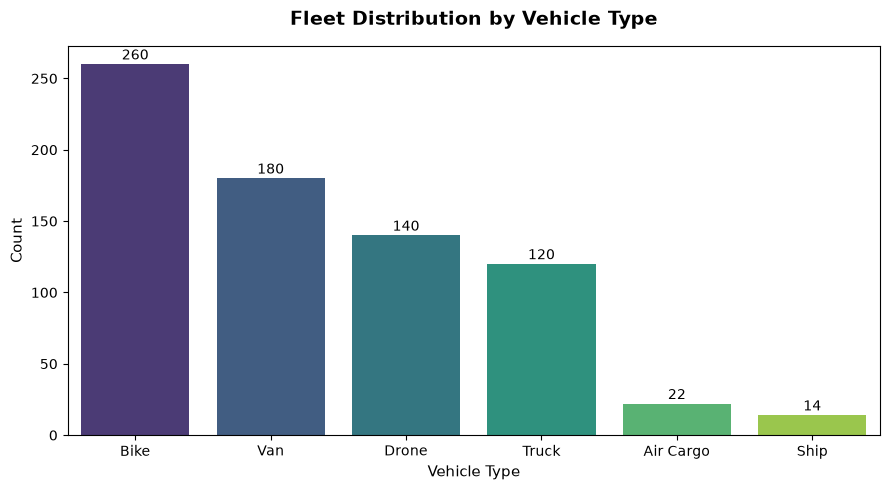

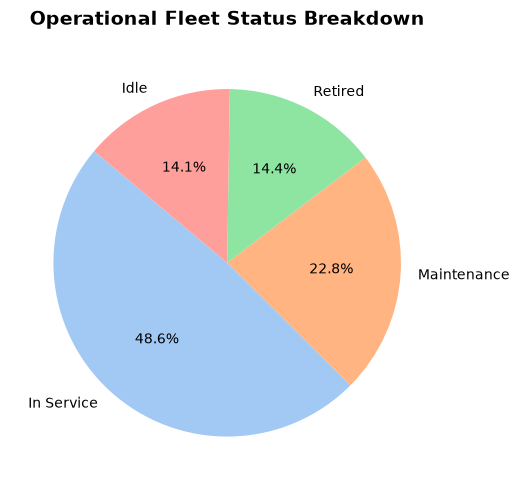

In [11]:
# 1. Vehicle Type Distribution Chart
plt.figure(figsize=(9, 5))
ax = sns.countplot(data=df, x='vehicle_type', order=df['vehicle_type'].value_counts().index, palette='viridis')
plt.title('Fleet Distribution by Vehicle Type', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Vehicle Type', fontsize=11)
plt.ylabel('Count', fontsize=11)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontsize=10)
plt.tight_layout()
plt.show()
plt.close()

# 2. Fleet Status Distribution Chart
plt.figure(figsize=(7, 5))
status_counts = df['fleet_status'].value_counts()
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Operational Fleet Status Breakdown', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
plt.close()